# DATA425 Lab 7: Denoising Autoencoders, Bottlenecks, Manifolds, and Anomaly Detection

In this lab, we use small handwritten digit images to learn what an autoencoder is doing internally. The model receives an input, compresses it into a smaller code, and reconstructs the input from that code.

You will work through:

- the encoder, bottleneck or code, and decoder structure,
- reconstruction loss,
- why a bottleneck discourages simple copying,
- how denoising connects to the manifold idea,
- how a denoising autoencoder removes noise,
- how reconstruction error can act as a simple anomaly signal.

Keep the central question in mind: what information must survive the bottleneck so that the decoder can rebuild a clean, digit-like image?

## Conceptual map

A denoising autoencoder is trained with this pattern:

$$
\text{corrupted input} \rightarrow \text{encoder} \rightarrow \text{code} \rightarrow \text{decoder} \rightarrow \text{clean reconstruction}.
$$

The model sees a noisy version of the input, but the target is the clean version. This matters because we are not training the model to copy noise. We are training it to learn the structure of real digit images and pull corrupted inputs back toward that structure.

A useful mental picture is the manifold intuition. Most real-looking digits occupy only a small part of the full 64-dimensional pixel space. Noise can push an image away from that region. A denoising autoencoder learns to map the noisy input back toward the region where clean digits live.

In [ ]:
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA


def set_seed(seed=425):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

set_seed(425)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load and prepare the image data

The digits are 8×8 grayscale images. A dense autoencoder expects each input as a vector, so we flatten each image from an 8×8 grid into 64 numbers.

We also scale the pixel values to `[0, 1]`. This matches the final `Sigmoid` layer in the decoder, which also outputs values between 0 and 1.

Even though the model uses flattened vectors here, remember that each vector still represents an image. When we plot the data, we reshape each 64-value vector back into an 8×8 grid so you can inspect the reconstruction visually.

In [ ]:
digits = load_digits()
images = digits.images.astype("float32") / 16.0
labels = digits.target.astype("int64")
flat = images.reshape(len(images), -1)

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    flat, labels, images, test_size=0.25, stratify=labels, random_state=425
)
X_train, X_val, y_train, y_val, img_train, img_val = train_test_split(
    X_train, y_train, img_train, test_size=0.20, stratify=y_train, random_state=425
)

print("Flattened training shape:", X_train.shape)
print("Each image has", X_train.shape[1], "input features = 8×8 pixels")
print("Train/val/test sizes:", len(X_train), len(X_val), len(X_test))

Flattened training shape: (1077, 64)
Each image has 64 input features = 8×8 pixels
Train/val/test sizes: 1077 270 450


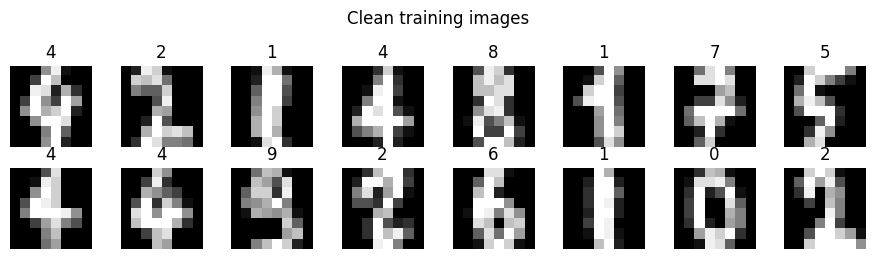

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, img, lab in zip(axes.ravel(), img_train[:16], y_train[:16]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(lab))
    ax.axis("off")
plt.suptitle("Clean training images")
plt.tight_layout()
plt.show()

## 2. Corrupt the inputs with noise

The denoising task is deliberately harder than ordinary reconstruction. We create noisy inputs with:

$$
\tilde{x} = \operatorname{clip}(x + \epsilon, 0, 1), \qquad \epsilon \sim \mathcal{N}(0, \sigma^2).
$$

Here $x$ is the clean image and $\tilde{x}$ is the corrupted image. The `clip` step keeps pixel values inside the valid range `[0, 1]`.

The important training setup is:

$$
\text{input} = \tilde{x}, \qquad \text{target} = x.
$$

After the next cell, compare the clean and noisy rows. The baseline MSE tells us how bad it would be to simply return the noisy image unchanged. A useful denoising model should beat that baseline.

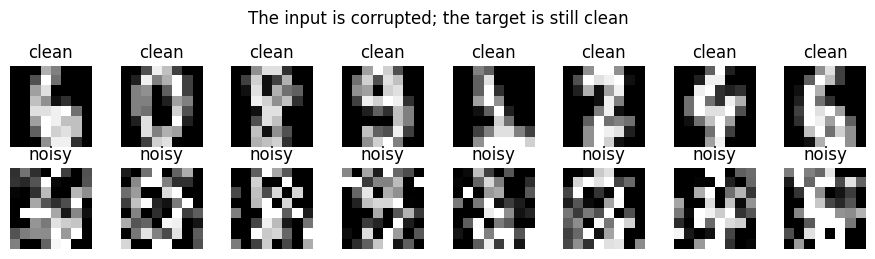

Baseline MSE if we output the noisy image unchanged: 0.1302


In [ ]:
def add_noise_np(X, noise_std=0.55, seed=425):
    rng = np.random.default_rng(seed)
    noisy = X + rng.normal(0, noise_std, size=X.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0)

noise_std = 0.55
X_test_noisy = add_noise_np(X_test, noise_std=noise_std, seed=1)

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, img in zip(axes[0], X_test[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    ax.set_title("clean")
    ax.axis("off")
for ax, img in zip(axes[1], X_test_noisy[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    ax.set_title("noisy")
    ax.axis("off")
plt.suptitle("The input is corrupted; the target is still clean")
plt.tight_layout()
plt.show()

baseline_mse = np.mean((X_test_noisy - X_test) ** 2)
print(f"Baseline MSE if we output the noisy image unchanged: {baseline_mse:.4f}")

## 3. Define an autoencoder with a real bottleneck

The input has 64 dimensions, but the code has only 8 dimensions. This narrow code is the bottleneck.

The bottleneck is important because it prevents the model from using an easy shortcut. If the code were as large as the input, the network might learn to copy every pixel, including noise. With only 8 numbers, it must keep the information that helps reconstruct digit-like structure and discard information that is less useful.

The encoder compresses:

$$
64 \rightarrow 32 \rightarrow 16 \rightarrow 8,
$$

and the decoder expands:

$$
8 \rightarrow 16 \rightarrow 32 \rightarrow 64.
$$

The final `Sigmoid` layer keeps the reconstructed pixels in `[0, 1]`.

In [ ]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim=64, code_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, code_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(code_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))


ae = DenoisingAutoencoder(code_dim=8).to(device)
print(ae)
print("Trainable parameters:", sum(p.numel() for p in ae.parameters() if p.requires_grad))

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 5544


In [ ]:
def make_flat_loader(X, batch_size=64, shuffle=True):
    tensor = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = make_flat_loader(X_train, batch_size=64, shuffle=True)
val_clean = torch.tensor(X_val, dtype=torch.float32, device=device)
val_noisy = torch.clamp(val_clean + noise_std * torch.randn_like(val_clean), 0.0, 1.0)


def train_denoising_autoencoder(model, train_loader, val_clean, val_noisy, epochs=35, lr=1e-3, noise_std=0.55):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, n = 0.0, 0
        for (xb,) in train_loader:
            xb = xb.to(device)
            noisy = torch.clamp(xb + noise_std * torch.randn_like(xb), 0.0, 1.0)
            optimizer.zero_grad()
            recon = model(noisy)
            loss = F.mse_loss(recon, xb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            n += xb.size(0)
        model.eval()
        with torch.no_grad():
            val_recon = model(val_noisy)
            val_loss = F.mse_loss(val_recon, val_clean).item()
        history.append({"epoch": epoch, "train_mse": total_loss / n, "val_mse": val_loss})
        if epoch in {1, 2, 5, 10, 20, epochs}:
            print(f"epoch {epoch:02d} | train MSE {total_loss / n:.4f} | val MSE {val_loss:.4f}")
    return pd.DataFrame(history)

history = train_denoising_autoencoder(ae, train_loader, val_clean, val_noisy, epochs=35, lr=1e-3, noise_std=noise_std)

epoch 01 | train MSE 0.1698 | val MSE 0.1621
epoch 02 | train MSE 0.1511 | val MSE 0.1332
epoch 05 | train MSE 0.0758 | val MSE 0.0745


epoch 10 | train MSE 0.0735 | val MSE 0.0732


epoch 20 | train MSE 0.0730 | val MSE 0.0727


epoch 35 | train MSE 0.0656 | val MSE 0.0653


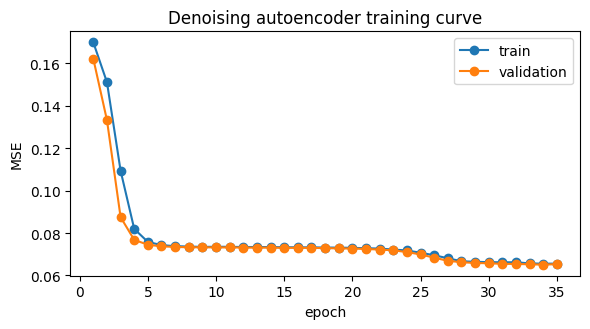

In [ ]:
plt.figure(figsize=(6, 3.4))
plt.plot(history["epoch"], history["train_mse"], marker="o", label="train")
plt.plot(history["epoch"], history["val_mse"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Denoising autoencoder training curve")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Confirm the intended outcome: noisy input to clean reconstruction

A denoising autoencoder is useful only if it improves on the simple baseline of returning the noisy image unchanged.

The next cell compares:

- **baseline MSE:** the error between noisy input and clean target,
- **autoencoder MSE:** the error between reconstruction and clean target.

Lower MSE means the reconstruction is closer to the clean image. The plotted rows are just as important as the number: look for whether the reconstructions remove random speckles while keeping the digit shape recognizable.

Noisy-input baseline MSE: 0.1302
Denoising autoencoder MSE: 0.0668
Improvement ratio baseline / autoencoder: 1.95×


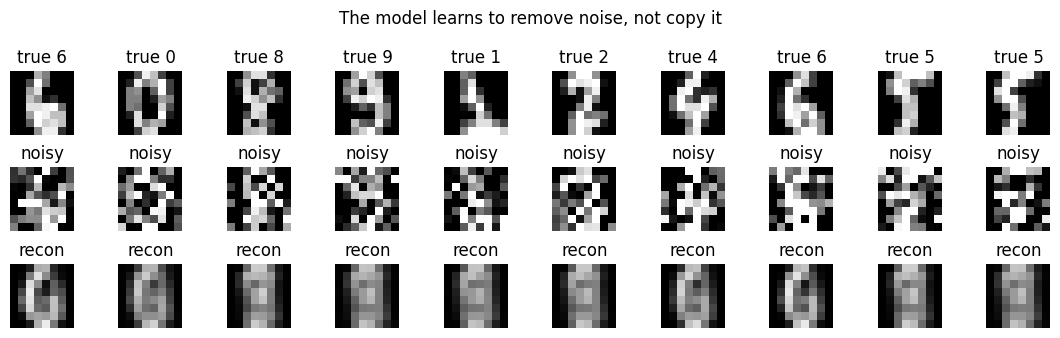

In [ ]:
ae.eval()
with torch.no_grad():
    test_noisy_tensor = torch.tensor(X_test_noisy, dtype=torch.float32, device=device)
    test_clean_tensor = torch.tensor(X_test, dtype=torch.float32, device=device)
    recon = ae(test_noisy_tensor).cpu().numpy()

denoised_mse = np.mean((recon - X_test) ** 2)
print(f"Noisy-input baseline MSE: {baseline_mse:.4f}")
print(f"Denoising autoencoder MSE: {denoised_mse:.4f}")
print(f"Improvement ratio baseline / autoencoder: {baseline_mse / denoised_mse:.2f}×")

fig, axes = plt.subplots(3, 10, figsize=(11, 3.4))
for j in range(10):
    axes[0, j].imshow(X_test[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"true {y_test[j]}")
    axes[1, j].imshow(X_test_noisy[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("noisy")
    axes[2, j].imshow(recon[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[2, j].set_title("recon")
    for i in range(3):
        axes[i, j].axis("off")
plt.suptitle("The model learns to remove noise, not copy it")
plt.tight_layout()
plt.show()

## 5. Inspect the learned code or embedding

The code is the compressed representation learned by the encoder. Each test image becomes an 8-dimensional vector.

Eight dimensions are hard to plot directly, so we use PCA to project the codes down to two dimensions for visualization. PCA is only used for plotting here. It is not part of the autoencoder.

When you inspect the scatter plot, look for whether similar digits tend to appear near each other. The clusters do not need to be perfect. The purpose is to see that the bottleneck has learned a more organized representation than raw pixels.

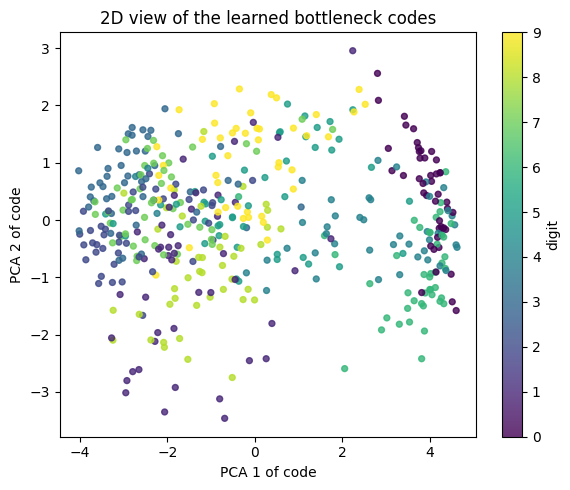

Code matrix shape: (450, 8)
Each 64-pixel image is represented by only 8 numbers.


In [ ]:
ae.eval()
with torch.no_grad():
    codes = ae.encode(torch.tensor(X_test, dtype=torch.float32, device=device)).cpu().numpy()

codes_2d = PCA(n_components=2, random_state=425).fit_transform(codes)
plt.figure(figsize=(6, 5))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test, s=18, alpha=0.8)
plt.colorbar(scatter, ticks=range(10), label="digit")
plt.title("2D view of the learned bottleneck codes")
plt.xlabel("PCA 1 of code")
plt.ylabel("PCA 2 of code")
plt.tight_layout()
plt.show()

print("Code matrix shape:", codes.shape)
print("Each 64-pixel image is represented by only", codes.shape[1], "numbers.")

## 6. Train on digits 0-4 and use reconstruction error for anomaly detection

Autoencoders usually reconstruct best the kinds of examples they have seen during training. We can turn that into a simple anomaly-detection idea.

Here we train a new autoencoder only on digits `0` to `4`. Digits `5` to `9` are outside the training distribution. If the model has learned the structure of only `0` to `4`, then it should struggle more with `5` to `9`.

The signal we use is reconstruction error:

$$
\text{high reconstruction error} \Rightarrow \text{possibly unusual input}.
$$

This is not a perfect anomaly detector, but it is a clear example of how a generative or reconstruction-based model can be used beyond ordinary prediction.

In [ ]:
seen_train_mask = y_train <= 4
seen_val_mask = y_val <= 4
seen_test_mask = y_test <= 4
unseen_test_mask = y_test >= 5

X_seen_train = X_train[seen_train_mask]
X_seen_val = X_val[seen_val_mask]
X_seen_test = X_test[seen_test_mask]
X_unseen_test = X_test[unseen_test_mask]
y_unseen_test = y_test[unseen_test_mask]

seen_model = DenoisingAutoencoder(code_dim=8).to(device)
seen_loader = make_flat_loader(X_seen_train, batch_size=64, shuffle=True)
seen_val_clean = torch.tensor(X_seen_val, dtype=torch.float32, device=device)
seen_val_noisy = torch.clamp(seen_val_clean + 0.10 * torch.randn_like(seen_val_clean), 0.0, 1.0)

print("Training examples for the 0–4-only autoencoder:", len(X_seen_train))
seen_history = train_denoising_autoencoder(
    seen_model, seen_loader, seen_val_clean, seen_val_noisy, epochs=80, lr=1e-3, noise_std=0.10
)

Training examples for the 0–4-only autoencoder: 539
epoch 01 | train MSE 0.1823 | val MSE 0.1796
epoch 02 | train MSE 0.1783 | val MSE 0.1751
epoch 05 | train MSE 0.1446 | val MSE 0.1270


epoch 10 | train MSE 0.0759 | val MSE 0.0747


epoch 20 | train MSE 0.0736 | val MSE 0.0730


epoch 80 | train MSE 0.0426 | val MSE 0.0408


Mean reconstruction error for seen digits 0–4:   0.0433
Mean reconstruction error for unseen digits 5–9: 0.0697
Unseen/seen error ratio: 1.61×


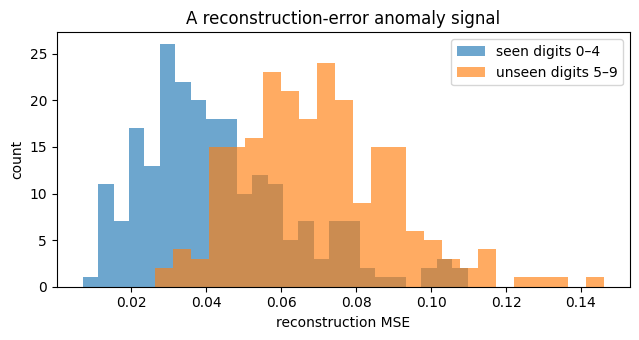

In [ ]:
def per_sample_mse(model, X):
    model.eval()
    with torch.no_grad():
        clean = torch.tensor(X, dtype=torch.float32, device=device)
        recon = model(clean).cpu().numpy()
    return np.mean((recon - X) ** 2, axis=1), recon

seen_errors, seen_recon = per_sample_mse(seen_model, X_seen_test)
unseen_errors, unseen_recon = per_sample_mse(seen_model, X_unseen_test)

print(f"Mean reconstruction error for seen digits 0–4:   {seen_errors.mean():.4f}")
print(f"Mean reconstruction error for unseen digits 5–9: {unseen_errors.mean():.4f}")
print(f"Unseen/seen error ratio: {unseen_errors.mean() / seen_errors.mean():.2f}×")

plt.figure(figsize=(6.5, 3.5))
plt.hist(seen_errors, bins=25, alpha=0.65, label="seen digits 0–4")
plt.hist(unseen_errors, bins=25, alpha=0.65, label="unseen digits 5–9")
plt.xlabel("reconstruction MSE")
plt.ylabel("count")
plt.title("A reconstruction-error anomaly signal")
plt.legend()
plt.tight_layout()
plt.show()

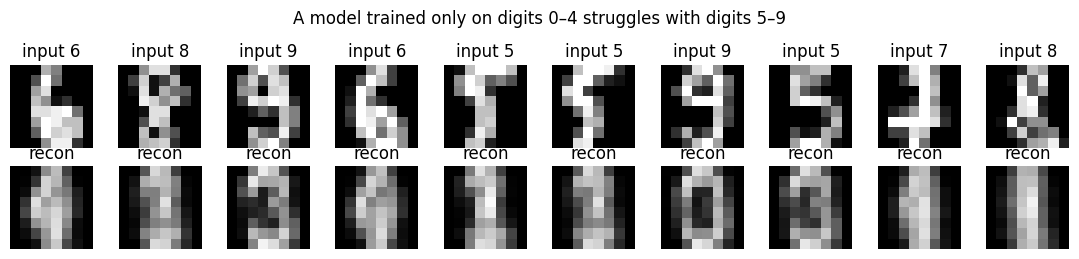

In [ ]:
# Show how the 0–4-only model handles out-of-manifold digits.
fig, axes = plt.subplots(2, 10, figsize=(11, 2.6))
for j in range(10):
    axes[0, j].imshow(X_unseen_test[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"input {y_unseen_test[j]}")
    axes[1, j].imshow(unseen_recon[j].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[1, j].set_title("recon")
    for i in range(2):
        axes[i, j].axis("off")
plt.suptitle("A model trained only on digits 0–4 struggles with digits 5–9")
plt.tight_layout()
plt.show()

## Lab takeaways

A denoising autoencoder learns from corrupted inputs and clean targets. The bottleneck discourages trivial copying and encourages the model to keep the structure needed to reconstruct realistic data. When an input is close to the learned data manifold, the decoder can often pull it back toward a clean version. When an input is far from what the model learned, reconstruction error tends to increase.

The same pattern appears in many applications: compress, reconstruct, and use reconstruction quality to understand what the model has learned.

### Suggested extensions

1. Change the bottleneck from 8 dimensions to 2, 16, or 64. What happens to denoising quality?
2. Increase the noise level. At what point does denoising fail?
3. Train only on one digit class and use reconstruction error to detect every other digit.
4. Replace MSE with binary cross-entropy and compare reconstructions.
5. Add sparsity by penalizing the absolute value of the code: `loss = reconstruction_loss + λ * code.abs().mean()`.